<a href="https://colab.research.google.com/github/ats202305/Spring-Symposium-Geometry-of-the-Wild/blob/main/SymposiumCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

#needed to install ripser
!pip install ripser

#for numerical calculations, and handling tables
import numpy as np
import pandas as pd

#computes persistent homology from a point cloud -  ripser uses a veitoris-rips filtration
from ripser import ripser
#all for model building and analytics - imputer handles missing entries with a median value, for example
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

#for modelling with umap clustering
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


## Making a function for the sliding windows so we can reuse it within other species

In [2]:

#this function creates the overlapping windows for one animal
#takes in the dataframe, automatically calculates the window with 20 points
#and the step size (the start of each next window moves by 5)
#we create a slight overlap by doing 5 and 20
def slidingWindows( animalData, windowSize = 20, stepSize = 5 ):
  #making an empty list to store the windows
  windows = []

  #storing the number of points for that animal
  n = len(animalData)

  #for i starting from 0 going to the last valid starting spot, iterating by the stepsize
  for i in range(0, n - windowSize + 1, stepSize):
    #this initiates our index of the current window
    end = i + windowSize
    #grabbing rows from i up to end and copying them into the window
    window = animalData[i:end].copy()
    #adds the window in the previous variable to the windows list
    windows.append(window)
  #returning those
  return windows


## Computing Movement Features

In [3]:

#function computes the movement stats for the window
def computeMovementFeatures(window):

  #making an empty features dictionary
  features = {}

  #making numerical arrays of the latitudes and longitudes in the window
  lon = window["location-long"].to_numpy()
  lat = window["location-lat"].to_numpy()

  #calculating basic means and standard deviations
  features["longMean"] = np.mean(lon)
  features["longSTD"] = np.std(lon)
  features["latMean"] = np.mean(lat)
  features["latSTD"] = np.std(lat)

  #also finding the change from the first point to the last point for each -  directional displacement
  features["deltaLong"] = lon[-1] - lon[0]
  features["deltaLat"] = lat[-1] - lat[0]

  #finds the consecutive change between the points - step to step
  dx = np.diff(lon)
  dy = np.diff(lat)
  #computes the Euclidean step lengths between said consecutive change points
  #this isn't a true distance, just approximation
  stepLengths = np.sqrt(dx**2 + dy**2)

  #just a couple measure statistics - if the length is 0 - it just returns 0 for no worries of potential errors
  features["stepMean"] = np.mean(stepLengths) if len(stepLengths) > 0 else 0.0
  features["stepSTD"] = np.std(stepLengths) if len(stepLengths) > 0 else 0.0
  features["stepMax"] = np.max(stepLengths) if len(stepLengths) > 0 else 0.0
  features["totalPath"] = np.sum(stepLengths) if len(stepLengths) > 0 else 0.0

  totalPath = np.sum(stepLengths)

  if totalPath > 0:
    features["straightness"] = np.sqrt((lon[-1] - lon[0])**2 + (lat[-1] - lat[0])**2) / totalPath
  else:
    features["straightness"] = 0.0
  #if straightness is near 1, its a straighter movement, if it's closer to 0, then there may be more loopy movement occuring


  return features


## Computing Persistent Homology

In [4]:

#Computes the persistent homology features for a window
def PersistentHomology(window):

  #empty dictionary as for prior function
  features = {}

  #grabs the longitude, latitude pairs as a numpy array
  points = window[["location-long", "location-lat"]].to_numpy()

  #seeing if the window has not enough points, with a lack of points, PH loses meaning or potentially becomes unstable
  if len(points) < 5:
    features["h0TotPersist"] = 0.0  #this means the total persistence of connected components
    features["h1TotPersist"] = 0.0  # total persistence of loops
    features["h1MaxPersist"] = 0.0 # strongest loop persistence
    features["h1NumFeats"] = 0.0 # number of finite H_1 features
    return features

  #Where the topological data analysis occurs
  #ripser computes the persistent homology of the point cloud by Vietoris-Rips filtration
  #Only computing up to one dimension - so it includes H_0 and H_1
  #dgms extracts the persistence diagrams - each row consists of births and deaths
  # births are where the feature appears, and deaths is where it disappears - persistence is death - birth
  diagrams = ripser(points, maxdim = 1)["dgms"]
  diagrams0 = diagrams[0]
  diagrams1 = diagrams[1]

  #this turns our persistence diagram to a vector of persistences - takes in the ripser diagram
  def persistLength(diagram):
    #checking if our diagram is empty - then we create an array that returns empty values for births, deaths, and persistences
    if len(diagram) == 0:
      empty = np.array([])
      return empty, empty, empty

    #otherwise, we grab all rows of the first column to grab all the birth times, and all rows of the second for death times
    births = diagram[:, 0]
    deaths = diagram[:, 1]

    #true if finite, false if not
    finiteFilt = np.isfinite(deaths)
    #filtering out both arrays with this filter
    #this is due to the fact that one component persists forever in H_0, so we remove it since it would break stats
    births = births[finiteFilt]
    deaths = deaths[finiteFilt]

    #computing the persistence - large means important topological feature, small means noise
    pers = deaths - births
    return births, deaths, pers

  #measure of disorder
  def persistentEntropy(pers):
    #if no features exist then we return 0
    if len(pers) == 0:
      return 0.0
    #otherwise, we sum up the persistent values
    total = np.sum(pers)
    #if the total is less than or equal to 0 we return 0
    if total <= 0:
      return 0.0
    #otherwise we normalize the persistent values as a probability
    p = pers / total
    #removing zeros
    p = p[p>0]

    #this is the Shannon entropy - so high entropy would mean spread out, heterogenous structure, low would be dominated by a few features - or one strong loop or cluster
    return -np.sum(p * np.log(p))

  #top 3 features and persistence values
  def topKSum(pers, k=3):
    #no features, then return 0
    if len(pers) == 0:
      return 0.0

    #sorts ascending, then makes it descending
    persSorted = np.sort(pers)[::-1]

    #grabbing the first 3 elements, and sums them up - captures the strongest features, more robust
    return np.sum(persSorted[:k])

  #applying the length function to the diagrams
  births0, deaths0, h0Pers = persistLength(diagrams0)
  births1, deaths1, h1Pers = persistLength(diagrams1)

  #calculating a bunch of feature statistics
  #fragmentation, strongest component, average, number of finite components, respectively
  features["h0TotPersist"] = np.sum(h0Pers) if len(h0Pers) > 0 else 0.0
  features["h0MaxPersist"] = np.max(h0Pers) if len(h0Pers) > 0 else 0.0
  features["h0MeanPersist"] = np.mean(h0Pers) if len(h0Pers) > 0 else 0.0
  features["h0NumFeats"] = len(h0Pers)

  #the value below which 75% persistence falls
  if len(h0Pers) > 0:
    h0Thresh = np.quantile(h0Pers, 0.75)
    #counts the amount of features above the 75% percentile -strong components
    features["h0NumStrongFeats"] = np.sum(h0Pers > h0Thresh)
  else:
    features["h0NumStrongFeats"] = 0

  #calculates the entropy of the persistence with the function
  features["h0Entropy"] = persistentEntropy(h0Pers)
  #uses the sum 3 function
  features["h0Top3Sum"] = topKSum(h0Pers)
  #average of where the components appear - clustering scale
  features["h0BirthMean"] = np.mean(births0) if len(births0) > 0 else 0.0

  #same situation as prior but with the h1 (loop) features
  #total loop strength, strongest loop, average loop length, number of loops, 75% percentile, number of strong loops respectively

  features["h1TotPersist"] = np.sum(h1Pers) if len(h1Pers) > 0 else 0.0
  features["h1MaxPersist"] = np.max(h1Pers) if len(h1Pers) > 0 else 0.0
  features["h1MeanPersist"] = np.mean(h1Pers) if len(h1Pers) > 0 else 0.0
  features["h1NumFeats"] = len(h1Pers)

  if len(h1Pers) > 0:
      h1Thresh = np.quantile(h1Pers, 0.75)
      features["h1NumStrongFeats"] = np.sum(h1Pers > h1Thresh)
  else:
      features["h1NumStrongFeats"] = 0

  #diversity of loops, strength of dominant loops, average scale where loops form
  features["h1Entropy"] = persistentEntropy(h1Pers)
  features["h1Top3Sum"] = topKSum(h1Pers)
  features["h1BirthMean"] = np.mean(births1) if len(births1) > 0 else 0.0

  #return all computations
  return features


## Function to read in files and then run the preprocessing before making the models

In [5]:

#preprocessing function for each of the data files so we don't have to do this separately each time
def fileCleaner(fileName):

  #reading in the csv
  animalData = pd.read_csv(fileName)

  #keeping desired columns
  columnsNeeded =  ["timestamp", "location-long", "location-lat", "individual-local-identifier", "individual-taxon-canonical-name", "tag-local-identifier" ]
  animalData = animalData[columnsNeeded].copy()

  #converting the timestamps to datetime
  animalData["timestamp"] = pd.to_datetime(animalData["timestamp"], errors = "coerce")

  #drop rows with the missing longitudes/latitudes - i saw some missing
  animalData = animalData.dropna(subset = ["location-long", "location-lat"])

  #sorting by individual id and the timestamp
  animalData = animalData.sort_values(["individual-local-identifier", "timestamp"]).reset_index(drop=True)

  #retunring this sorted and cleaned data
  return animalData


In [6]:

#function used on the data after it is ran through the fileCleaner function so we can create the sliding windows and the movement and ph data based off of those
def buildFeatureData( animalData):

  #empty list
  allFeatureRows = []

  #groups the data by animal id
  groupedData = animalData.groupby("individual-local-identifier")

  #loops through each animal group
  for name, group in groupedData:
  #breaks that animals movement into the sliding windows
    windows = slidingWindows(group, windowSize = 20, stepSize = 5)

  #for i through each window from the bird
    for i, window in enumerate(windows):
    #compute the movement features and persistent homology features with our functions
      movementFeatures = computeMovementFeatures(window)
      phFeatures = PersistentHomology(window)

      #empty dictionary
      row = {}
      #stores animal id, window index for the animal, and then grabs the first rows value just because it should be the same species
      row["animalID"] = name
      row["windowIndex"] = i
      row["tagID"] = window["tag-local-identifier"].iloc[0]
      row["canonicalName"] = window["individual-taxon-canonical-name"].iloc[0]

    #puts all key-value pairs into the row dictionary from our functions
      row.update(movementFeatures)
      row.update(phFeatures)

    #one dictionary per sliding window across all birds
      allFeatureRows.append(row)

  #converts list to dataframe
  featureData = pd.DataFrame(allFeatureRows)

  return featureData


## Running the preprocessing on the datasets

In [7]:

#on each of the datasets loaded in, we are running the fileCleaner function to get everything preprocessed into the format we
#desire, and then we use the featureData builder function to create the features from the sliding windows so we can make our models off of it

ibis = fileCleaner("AmericanWhiteIbis.csv")
ibisFeatureData = buildFeatureData(ibis)

hare = fileCleaner("ArcticHareBunny.csv")
hareFeatureData = buildFeatureData(hare)

baboon = fileCleaner("Baboon.csv")
baboonFeatureData = buildFeatureData(baboon)

bbJackal = fileCleaner("BlackBackedJackal.csv")
bbJackalFeatureData = buildFeatureData(bbJackal)

blueWhale = fileCleaner("BlueWhale.csv")
blueWhaleFeatureData = buildFeatureData(blueWhale)

bickThrush = fileCleaner("BicknellsThrushBird.csv")
bickThrushFeatureData = buildFeatureData(bickThrush)

fKillerWhale = fileCleaner("FalseKillerWhale.csv")
fKillerWhaleFeatureData = buildFeatureData(fKillerWhale)

kinkajous = fileCleaner("Kinkajous.csv")
kinkajousFeatureData = buildFeatureData(kinkajous)

lion = fileCleaner("Lion.csv")
lionFeatureData = buildFeatureData(lion)



In [8]:

#same thing, just with more files so as to not take as long

mangabeyMonk = fileCleaner("MangabeyMonk.csv")
mangabeyMonkFeatureData = buildFeatureData(mangabeyMonk)

swampWallaby = fileCleaner("SwampWallaby.csv")
swampWallabyFeatureData = buildFeatureData(swampWallaby)

tRattle = fileCleaner("TigerRattlesnake.csv")
tRattleFeatureData = buildFeatureData(tRattle)

spermWhale = fileCleaner("SpermWhale.csv")
spermWhaleFeatureData = buildFeatureData(spermWhale)

wwBeest = fileCleaner("WhiteBeardWildebeest.csv")
wwBeestFeatureData = buildFeatureData(wwBeest)

cattle = fileCleaner("cattle.csv")
cattleFeatureData = buildFeatureData(cattle)

mantaRay = fileCleaner("mantaRay.csv")
mantaRayFeatureData = buildFeatureData(mantaRay)

## Beginning the modelling preprocessing and actual models - three separate models: one with only movement data, one with only persistent homology data, and the last one has both movement and ph data

In [9]:

#sticking all of the preprocessed data together into one large piece, ignoring the index
allFeatureData = pd.concat([ ibisFeatureData, hareFeatureData, baboonFeatureData, bbJackalFeatureData, blueWhaleFeatureData, bickThrushFeatureData, fKillerWhaleFeatureData, kinkajousFeatureData,
 lionFeatureData, mangabeyMonkFeatureData, swampWallabyFeatureData, tRattleFeatureData, wwBeestFeatureData, cattleFeatureData, spermWhaleFeatureData,  mantaRayFeatureData], ignore_index=True)

#pulling out the nonfeature columns just in case
nonFeatCols = ["animalID", "windowIndex", "tagID", "canonicalName"]

#pulling out the movement columns
movementCols = ["longMean", "longSTD", "latMean", "latSTD", "deltaLong", "deltaLat", "straightness", "stepMean", "stepSTD", "stepMax", "totalPath"]

#pulling out the ph columns
phCols = ["h0TotPersist", "h1TotPersist", "h1MaxPersist", "h1NumFeats", "h0MaxPersist", "h0MeanPersist", "h0NumFeats",
          "h0NumStrongFeats", "h0Entropy", "h0Top3Sum", "h0BirthMean", "h1MeanPersist", "h1NumStrongFeats", "h1Entropy", "h1Top3Sum", "h1BirthMean"]

#making new dataframes with the subsets of the columns - one movement, one ph, one all
XMovement = allFeatureData[movementCols]
XPH = allFeatureData[phCols]
XAll = allFeatureData[movementCols + phCols]



## Preprocessing the feature data - scaling it so all features can properly contribute to the distances (UMAP uses the distance between points)

In [13]:

#data input to the function is simply the feature data subsets we made previously
def preprocessFeatures(data):
  #making an imputer from simpleImputer, which replaces missing values with the median value of the column, just to make it more robust to outliers
  #PH especially could have some missing values or extreme values at that, so this takes that into consideration
  imputer = SimpleImputer(strategy = "median")

  #computing the median of each column and applying it as needed to our data (transform applies, fit computes)
  dataImp = imputer.fit_transform(data)

  #initializing our standard scaler
  #for each feature, this will subtract the mean and divide it by the standard deviation which scales it
  scaler = StandardScaler()
  #we then compute and apply it to the imputed data and put it into a new variable
  dataScaled = scaler.fit_transform(dataImp)

  #returning the scaled and imputed data
  return dataScaled

#this step is necessary to make sure our values are contributing equally, seeing as both movement and ph features could have a massive range of values, so this just helps with the weighting of everything

#applying the function to our three dataframes
XMovementScale = preprocessFeatures(XMovement)
XPHScale = preprocessFeatures(XPH)
XAllScale = preprocessFeatures(XAll)

In [14]:

#the colors we are using for the model, the default color size was 10 and we have 16 species, so we manually assigned colors so we had no duplicating colors
colors = ["#2ca02c", "#d62728", "#17becf", "#7a413d", "#0a6435", "#893402", "#bcb422", "#e276c1", "#7f7f7f",
          "#fe7e0e", "#9366bc", "#022889", "#1f77b4", "#c02e76", "#edcd15", "#d395ef" ]

## Creating, Running and Visualizing the Cluster Model for only movement features

In [19]:

#this model setup remains consistent for the sake of comparison, it might not be the most optimal setup for each, but it is a good baseline for comparison - definitely a realm of
#further exploration

#creating the model for the movement features
umapMove = umap.UMAP(
    #this is the size of the local neighborhood, or the amount of sample points for the manifold approx
    #more points give global views, smaller values give more local data (default is 15 so we went with default)
    n_neighbors=15,

    #this minimum distance between embedded points - small gives more clumped embedding,
    #larger values give more dispersed points
    #for our case using 0.1 is better for cluster visualization
    min_dist=0.1,
    #The dimension of the space to embed in - defaults to 2, but we are using it for visualization purposes as well
    n_components=2,
    #for reproducibility and consistency in model outputs
    random_state=15
)

#fit learns the structure of the data and builds the graph of the nearest neighbors, estimating manifold structure
#transform projects data into 2d
embMovement = umapMove.fit_transform(XMovementScale)

#first column x axis, second column y axis
allFeatureData["UMAPmove1"] = embMovement[:,0]
allFeatureData["UMAPmove2"] = embMovement[:,1]


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


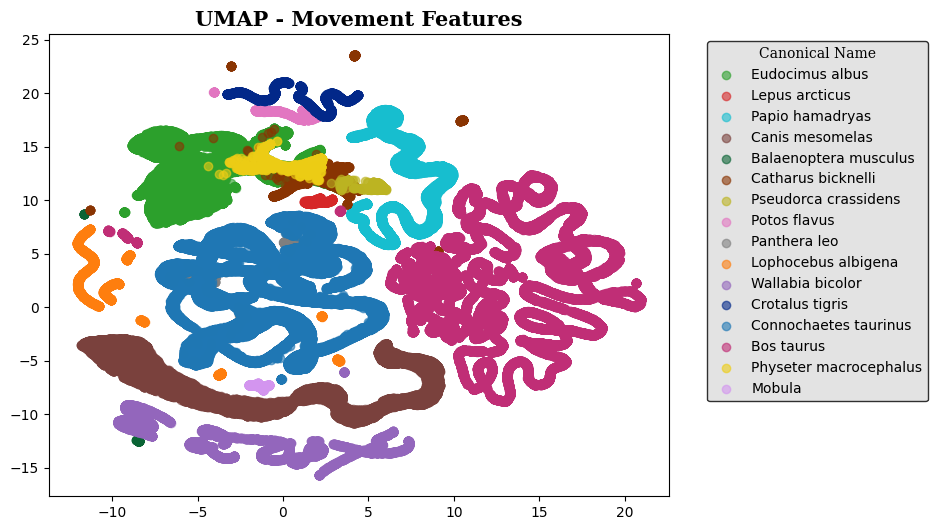

In [20]:

#the size of the figure
plt.figure(figsize=(8,6))

for i, sp in enumerate(allFeatureData["canonicalName"].unique()):
    subset = allFeatureData[allFeatureData["canonicalName"] == sp]
    plt.scatter(subset["UMAPmove1"], subset["UMAPmove2"], label=sp, alpha=0.6, color = colors[i % len(colors)])

plt.title("UMAP - Movement Features", font = "serif", fontweight = "bold", loc = "center", fontsize = 15)
plt.legend(bbox_to_anchor=(1.05,1), facecolor = "gainsboro", edgecolor = "black", loc = 0 , title = "Canonical Name", alignment = "center",
           title_fontproperties = "serif")
plt.show()

## Creating, Running and Visualizing the Cluster Model for only PH features

In [15]:


umapPH = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=15
)


embPH = umapPH.fit_transform(XPHScale)


allFeatureData["UMAPph1"] = embPH[:,0]
allFeatureData["UMAPph2"] = embPH[:,1]


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


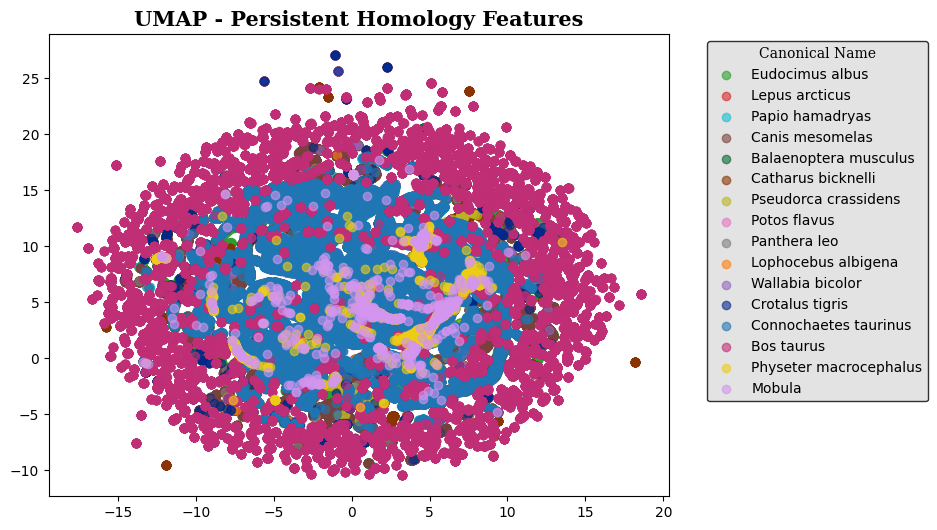

In [16]:

#visualizing in the same way as prior but with UMAP ph instead
plt.figure(figsize=(8,6))

for i, sp in enumerate(allFeatureData["canonicalName"].unique()):
    subset = allFeatureData[allFeatureData["canonicalName"] == sp]
    plt.scatter(subset["UMAPph1"], subset["UMAPph2"], label=sp, alpha=0.6, color = colors[i % len(colors)])

plt.title("UMAP - Persistent Homology Features", font = "serif", fontweight = "bold", loc = "center", fontsize = 15)
plt.legend(bbox_to_anchor=(1.05,1), facecolor = "gainsboro", edgecolor = "black", loc = 0 , title = "Canonical Name", alignment = "center",
           title_fontproperties = "serif")
plt.show()

## Creating, Running and Visualizing the Cluster Model for both PH and Movement Data

In [ ]:


umapBoth = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=15
)


embCombined = umapBoth.fit_transform(XAllScale)


allFeatureData["UMAPcomb1"] = embCombined[:,0]
allFeatureData["UMAPcomb2"] = embCombined[:,1]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


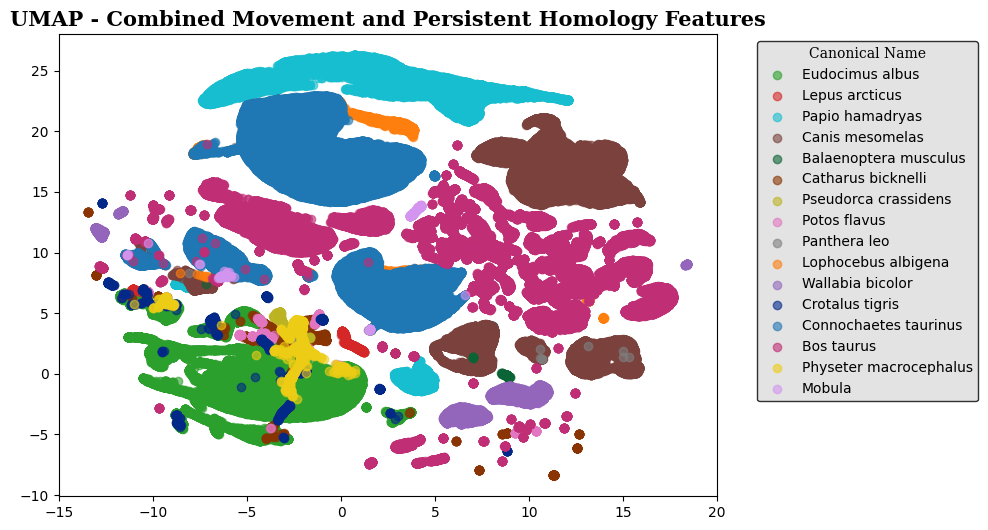

In [ ]:

#visualizing in the same way as prior, just with the UMAPcomb data
plt.figure(figsize=(8.5,6))

for i , sp in enumerate(allFeatureData["canonicalName"].unique()):
    subset = allFeatureData[allFeatureData["canonicalName"] == sp]
    plt.scatter(subset["UMAPcomb1"], subset["UMAPcomb2"], label=sp, alpha=0.6, color = colors[i % len(colors)])

plt.title("UMAP - Combined Movement and Persistent Homology Features", font = "serif", fontweight = "bold", loc = "center", fontsize = 15)
plt.legend(bbox_to_anchor=(1.05,1), facecolor = "gainsboro", edgecolor = "black", loc = 0 , title = "Canonical Name", alignment = "center",
           title_fontproperties = "serif")
plt.show()

# Visual of one individual animal of one species and its movements within its time of being tracked, along with the barcodes of that animal.

### looks messy but the point is to show the swirliness of the data and the movement over time.

In [32]:


#grabbing a single ibis animal tag to isolate its movement data
#taking the column, removing nan values, then grabbing the first unique value number, which is the first ibis tag number
oneIbis = ibis["tag-local-identifier"].dropna().unique()[0]

#filters the dataframe copies all of the data of that single id into a new datafr5ame
tagData = ibis[ibis["tag-local-identifier"] == oneIbis].copy()
#sorting the tag by the timestamp - chronological order
tagDataMove = tagData.sort_values("timestamp")

#extracting the first tracked point and the last tracked point
firstPoint = tagDataMove.iloc[0]
lastPoint = tagDataMove.iloc[-1]

#converting time into numeric values measure in seconds since first observation - to color the points by time later on
timeNumeric = (tagDataMove["timestamp"] - tagDataMove["timestamp"].min()).dt.total_seconds()


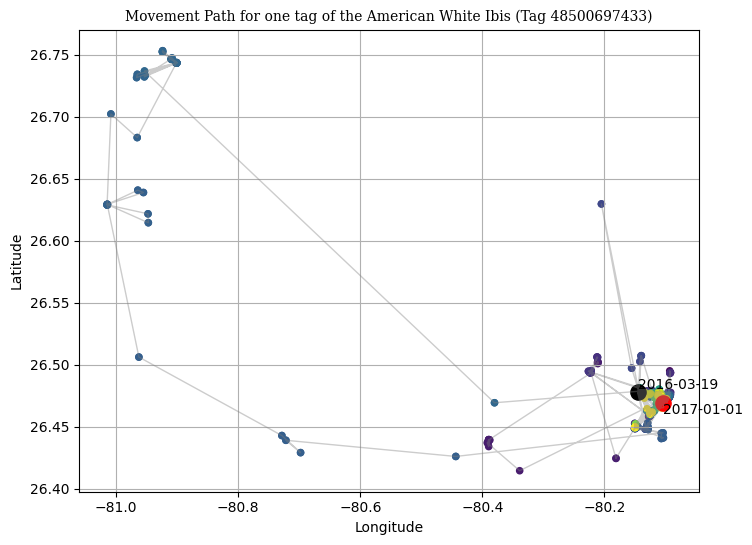

In [33]:

#making the plot of the lats and longs and time - plotting the movement path
#size of figure
plt.figure(figsize=(8,6))
#this draws the line connecting the movement points in time order - gray line that is slightly transparent so it isn't as distracting
plt.plot(tagDataMove["location-long"], tagDataMove["location-lat"], linestyle = "-", color = "gray", alpha = 0.4, linewidth = 1)

#drawing the actual movement points that are colored by time (timeNumeric) - since it increases over time, the point colors show that time progression
scatter = plt.scatter( tagDataMove["location-long"], tagDataMove["location-lat"], c = timeNumeric, cmap = "viridis", s = 20)

#plotting the first point again to highlight the start of the movement - s is the marker size so we can see it better
#plt.text is to show the date of the first gps read
plt.scatter( firstPoint["location-long"], firstPoint["location-lat"], s=120, color="black", label="Start")
plt.text( firstPoint["location-long"], firstPoint["location-lat"], firstPoint["timestamp"].strftime("%Y-%m-%d"), fontsize=10, verticalalignment="bottom")

#plotting the last point in the same fashion of the first point, so we can show when and where the last reading is done.
plt.scatter( lastPoint["location-long"], lastPoint["location-lat"], s=120, color="red", label="End")
plt.text( lastPoint["location-long"], lastPoint["location-lat"], lastPoint["timestamp"].strftime("%Y-%m-%d"), fontsize=10, verticalalignment="top")

#adding labels to axes and such
plt.title(f"Movement Path for one tag of the American White Ibis (Tag {oneIbis})", font = "Serif")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

#not the prettiest to read, but it shows how the data is and how the loops can cause meaning loss in certain formats

# Barcode visual for this instance of the ibis

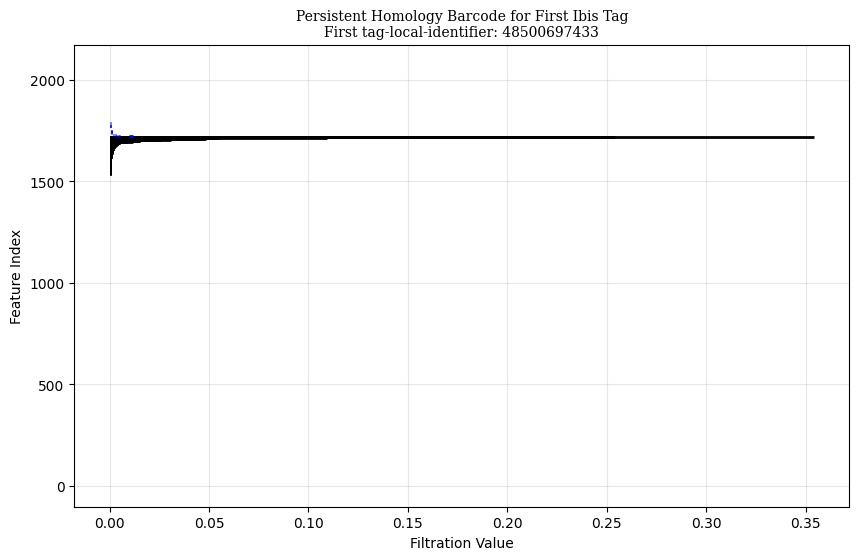

In [34]:


#building a point cloud and computing the persistent homology
#extracts the longs and lat columns and converts then to numpy arrays
points = tagData[["location-long", "location-lat"]].to_numpy()

# computing persistent homology on the point cloud
#maxdim is up to dimension 1 (so 0 and 1)
#h0 is connected components and h1 is loops
result = ripser(points, maxdim=1)
#extracting the diagrams from ripser
diagrams = result["dgms"]



# function to draw barcode plot
def plotBarcode(diagrams, title="Barcode Plot"):
    plt.figure(figsize=(10, 6))

    #initializing the vertical spot for the barcode lines
    y = 0
    colors = ["black", "blue"]  # H0 black, H1 blue

    #this loops through each homology dimension
    for dim, diagram in enumerate(diagrams):
      #goes through each persistence interval in that diagram
        for interval in diagram:
          #assigning the values of the birth and death from the filtration values
          #births are when filtration values when feature appear
          #deaths are when filtration values when the feature disappear
            birth, death = interval

            #replace infinite death with a finite plotting limit so it can properly be shown - happens with h0 often so needs to be dealt with
            if np.isinf(death):
                death = max(diagram[np.isfinite(diagram[:, 1]), 1], default=birth + 1) + 0.1

            #draws a horizontal barcode line
            #y=y where the line will be drawn, minimum values is the birth, maximum value is the death, colors assigned accordingly
            plt.hlines(y=y, xmin=birth, xmax=death, linewidth=2, color=colors[dim])
            #then we move to the next vertical row so the next barcode interval can be drawn above
            y += 1

    #labelling the plot
    plt.xlabel("Filtration Value")
    plt.ylabel("Feature Index")
    plt.title(f"{title}\nFirst tag-local-identifier: {oneIbis}", font = "Serif")
    plt.grid(alpha=0.3)
    plt.show()


# make the barcode visual for the full data - hard to read and interpret
plotBarcode(diagrams, title="Persistent Homology Barcode for First Ibis Tag")

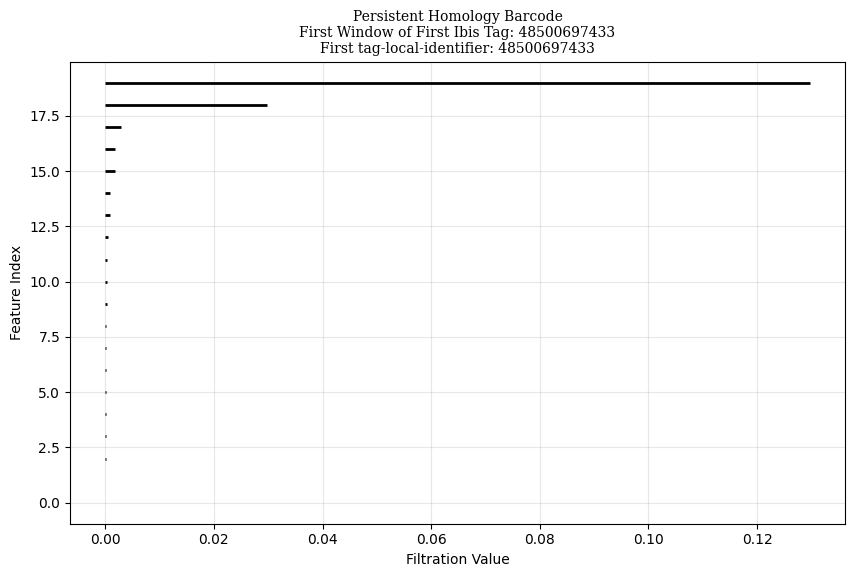

In [36]:


#computing the windows on the single bird data with the function from earlier
windows = slidingWindows(tagData, windowSize = 20, stepSize = 5)
#grabbing the first window from that
firstWindow = windows[0]

#build the point cloud for the window - selecting the long and lat and converting to numpy array
points = firstWindow[["location-long", "location-lat"]].to_numpy()

#compute persistent homology on the window as done previously - up to one dimension
result = ripser(points, maxdim=1)
diagrams = result["dgms"]

#plot barcode for one window - much easier to read and interpret
plotBarcode(diagrams, title=f"Persistent Homology Barcode\nFirst Window of First Ibis Tag: {oneIbis}")